# Notebook 11 — Recalibración de Umbrales + Análisis de Coste FP/FN

**Selección operacional del umbral** de cada detector según el contexto de despliegue (cuánto cuesta un falso positivo frente a un falso negativo). Hasta ahora todos los modelos usaban un umbral que maximiza F1 — matemáticamente neutro pero **operacionalmente arbitrario**. En ciberseguridad de *smart-grids* un **falso negativo** (ataque no detectado) suele ser **mucho más costoso** que un falso positivo (falsa alarma descartada tras revisión).

---

### ⚠️ Corrección metodológica (v2): calibración **sobre validación**, evaluación **sobre test**

La primera versión de este notebook elegía el umbral **directamente sobre el conjunto de test** y reportaba métricas sobre ese mismo test. Eso es una **fuga de información** (el umbral se ajusta a los datos con los que luego se mide), que infla optimistamente los resultados. Esta versión implementa el **protocolo correcto**, idéntico al que documenta `tfg_common` para todo el proyecto:

> **el umbral (F-beta y coste) se elige SOLO sobre `val_with_attacks`, y las métricas se reportan aplicando ese umbral fijo sobre `test_with_attacks`.**

Como los *scores* de validación no se habían persistido (solo existían los de test en `predictions_*.csv`), se **regeneran desde los modelos guardados** con el script `scripts/regen_val_scores.py`. Cada regeneración se **valida** comparando el *score* de test recreado contra la columna ya guardada en `predictions_*.csv`: solo se incluyen los detectores con **correlación > 0.99** (en la práctica, **corr = 1.00000**). Detectores verificados e incluidos: **Isolation Forest, Dense-AE (campeón edge) y LightGBM (techo supervisado)**.

> *Nota:* los AEs de ventana (LSTM/CNN/Transformer), KMeans+IF y el Stacking requieren su canalización de inferencia propia (ventaneo, MSE ponderado por ventana, meta-modelo) para regenerar sus *scores* de validación; quedan como extensión documentada. LightGBM es supervisado (entrenó sobre val), por lo que su umbral-en-val es ligeramente optimista y se marca como tal.

**Análisis incluido para cada detector:**
1. Curva **precision-recall** sobre test, con los puntos operativos elegidos en val.
2. Umbral que maximiza **F1**, **F2**, **F0.5** en val → P/R/F resultantes en test.
3. Umbral que minimiza el **coste esperado** en val para varios ratios `C_FN/C_FP ∈ {1, 5, 10, 20, 50}` → FP/FN/P/R en test.
4. **Cuantificación del sesgo**: F1 con umbral-en-test (v1, optimista) vs umbral-en-val (v2, honesto).

Resultado: una guía de decisión operacional **sin fuga de test**, lista para el capítulo "Selección operacional del umbral" de la memoria.


## 0. Setup

In [1]:
import os, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('OK')

from sklearn.metrics import (
    f1_score, fbeta_score, precision_recall_curve, roc_curve,
    average_precision_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix
)


OK


## 1. Carga de Datos + scores de todos los detectores

In [2]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'
DATA_DIR = os.path.join(BASE_DIR, 'data')

with open(os.path.join(DATA_DIR, 'pipeline_config.json')) as f:
    config = json.load(f)
FEATURE_COLS = config['feature_cols']
ATTACK_TYPES = config['attack_types']

# ── Scores de VALIDACION y TEST regenerados desde los modelos guardados ──
# (producidos por scripts/regen_val_scores.py; cada uno validado con corr>0.99 contra
#  la columna de score ya guardada en predictions_*.csv).
# Si faltan los .npy, ejecutar antes:  python scripts/regen_val_scores.py
VERIFIED = {
    'IF':       ('scores_val_if.npy',       'scores_test_if.npy',       'no supervisado'),
    'Dense-AE': ('scores_val_dense-ae.npy', 'scores_test_dense-ae.npy', 'no supervisado'),
    'LightGBM': ('scores_val_lightgbm.npy', 'scores_test_lightgbm.npy', 'supervisado*'),
}

y_val  = np.load(os.path.join(DATA_DIR, 'y_val_aligned.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test_aligned.npy'))

scores_val_d, scores_test_d, det_kind = {}, {}, {}
missing = []
for name, (fv, ft, kind) in VERIFIED.items():
    pv = os.path.join(DATA_DIR, fv); pt = os.path.join(DATA_DIR, ft)
    if os.path.exists(pv) and os.path.exists(pt):
        scores_val_d[name]  = np.load(pv)
        scores_test_d[name] = np.load(pt)
        det_kind[name] = kind
    else:
        missing.append(name)

print('SCORES CARGADOS (val regenerado + test) — corr de verificacion = 1.00000')
print('=' * 62)
print(f'  Val:  {len(y_val):>8,d} muestras  ({int(y_val.sum()):,} ataques, '
      f'{100*y_val.mean():.1f}%)')
print(f'  Test: {len(y_test):>8,d} muestras  ({int(y_test.sum()):,} ataques, '
      f'{100*y_test.mean():.1f}%)')
print('-' * 62)
for name in scores_val_d:
    print(f'  > {name:10s} [{det_kind[name]:14s}]  '
          f'val={scores_val_d[name].shape[0]:,}  test={scores_test_d[name].shape[0]:,}')
if missing:
    print(f'\n  ⚠️  Faltan .npy de: {missing} -> ejecuta `python scripts/regen_val_scores.py`')


SCORES CARGADOS (val regenerado + test) — corr de verificacion = 1.00000
  Val:   144,452 muestras  (21,739 ataques, 15.0%)
  Test:  604,999 muestras  (96,717 ataques, 16.0%)
--------------------------------------------------------------
  > IF         [no supervisado]  val=144,452  test=604,999
  > Dense-AE   [no supervisado]  val=144,452  test=604,999
  > LightGBM   [supervisado*  ]  val=144,452  test=604,999


## 2. Recalibración por F-beta

In [3]:
def thr_fbeta_on_val(y_val, s_val, beta):
    """Umbral que maximiza F_beta SOBRE VALIDACION."""
    p, r, thr = precision_recall_curve(y_val, s_val)
    p, r = p[:-1], r[:-1]
    fbeta = ((1+beta**2)*p*r) / (beta**2*p + r + 1e-10)
    return thr[int(np.argmax(fbeta))]

def report_at(y, s, thr):
    """P/R/F1/F2/F0.5 al aplicar un umbral fijo."""
    yp = (s > thr).astype(int)
    return dict(
        P=precision_score(y, yp, zero_division=0),
        R=recall_score(y, yp, zero_division=0),
        F1=fbeta_score(y, yp, beta=1.0, zero_division=0),
        F2=fbeta_score(y, yp, beta=2.0, zero_division=0),
        F05=fbeta_score(y, yp, beta=0.5, zero_division=0),
    )

# Protocolo: umbral elegido en VAL (beta), metricas reportadas en TEST.
print('='*92)
print('  F-BETA  -- umbral elegido en VALIDACION, P/R/F reportados en TEST')
print('='*92)
print(f'  {"Detector":10s} {"thr(val)":>9s} '
      f'| {"F1@test":>8s} {"P":>6s} {"R":>6s} '
      f'| {"F2@test":>8s} {"P":>6s} {"R":>6s} '
      f'| {"F0.5@test":>9s} {"P":>6s} {"R":>6s}')
print('-'*92)
recommendations = []
for name in scores_val_d:
    sv, st = scores_val_d[name], scores_test_d[name]
    rec = {'detector': name, 'tipo': det_kind[name]}
    for beta, tag in [(1.0, 'F1'), (2.0, 'F2'), (0.5, 'F0.5')]:
        thr = thr_fbeta_on_val(y_val, sv, beta)
        m = report_at(y_test, st, thr)
        rec[f'thr_{tag}'] = thr
        rec[tag] = m['F1' if tag == 'F1' else ('F2' if tag == 'F2' else 'F05')]
        rec[f'P_{tag}'] = m['P']; rec[f'R_{tag}'] = m['R']
    recommendations.append(rec)
    print(f'  {name:10s} {rec["thr_F1"]:>9.4f} '
          f'| {rec["F1"]:>8.4f} {rec["P_F1"]:>6.3f} {rec["R_F1"]:>6.3f} '
          f'| {rec["F2"]:>8.4f} {rec["P_F2"]:>6.3f} {rec["R_F2"]:>6.3f} '
          f'| {rec["F0.5"]:>9.4f} {rec["P_F0.5"]:>6.3f} {rec["R_F0.5"]:>6.3f}')
rec_df = pd.DataFrame(recommendations)
print('\n  * LightGBM es supervisado (entreno sobre val): su umbral-en-val es '
      'ligeramente optimista.')

  F-BETA  -- umbral elegido en VALIDACION, P/R/F reportados en TEST
  Detector    thr(val) |  F1@test      P      R |  F2@test      P      R | F0.5@test      P      R
--------------------------------------------------------------------------------------------


  IF            0.5580 |   0.7464  0.752  0.741 |   0.7976  0.615  0.861 |    0.7762  0.816  0.650


  Dense-AE      0.5158 |   0.8229  0.863  0.787 |   0.8201  0.724  0.848 |    0.8681  0.912  0.727


  LightGBM      0.5099 |   0.9151  0.960  0.875 |   0.8941  0.934  0.885 |    0.9468  0.969  0.869

  * LightGBM es supervisado (entreno sobre val): su umbral-en-val es ligeramente optimista.


## 3. Recalibración por coste esperado

In [4]:
def best_threshold_cost_on_val(y_val, s_val, c_fn, c_fp, n_thr=300):
    """Umbral que minimiza el coste esperado SOBRE VALIDACION."""
    grid = np.unique(np.linspace(s_val.min(), s_val.max(), n_thr))
    best_cost, best_thr = np.inf, grid[0]
    for thr in grid:
        yp = (s_val > thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, yp, labels=[0, 1]).ravel()
        c = c_fn * fn + c_fp * fp
        if c < best_cost:
            best_cost, best_thr = c, thr
    return best_thr

COST_RATIOS = [1, 5, 10, 20, 50]   # C_FN / C_FP
C_FP = 1.0

rows_cost = []
for name in scores_val_d:
    sv, st = scores_val_d[name], scores_test_d[name]
    row = {'detector': name}
    for ratio in COST_RATIOS:
        thr_c = best_threshold_cost_on_val(y_val, sv, ratio * C_FP, C_FP)  # en VAL
        yp = (st > thr_c).astype(int)                                      # en TEST
        tn, fp, fn, tp = confusion_matrix(y_test, yp, labels=[0, 1]).ravel()
        row[f'thr_C={ratio}']  = thr_c
        row[f'FP_C={ratio}']   = int(fp)
        row[f'FN_C={ratio}']   = int(fn)
        row[f'rec_C={ratio}']  = recall_score(y_test, yp, zero_division=0)
        row[f'prec_C={ratio}'] = precision_score(y_test, yp, zero_division=0)
    rows_cost.append(row)

cost_df = pd.DataFrame(rows_cost)
print('Umbral elegido en VAL por ratio de coste C_FN/C_FP; FP/FN/P/R medidos en TEST:')
print(cost_df.set_index('detector').round(4))
print('\nLectura: a mayor C_FN/C_FP el umbral baja -> mas recall (menos FN) a costa de mas FP.')

Umbral elegido en VAL por ratio de coste C_FN/C_FP; FP/FN/P/R medidos en TEST:
          thr_C=1  FP_C=1  FN_C=1  rec_C=1  prec_C=1  thr_C=5  FP_C=5  FN_C=5  \
detector                                                                        
IF         0.5740   17066   30157   0.6882    0.7959   0.5052   51899   13444   
Dense-AE  14.8734     640   82421   0.1478    0.9572  14.8734     640   82421   
LightGBM   0.5179    3475   12192   0.8739    0.9605   0.3526    6315   11070   

          rec_C=5  prec_C=5  ...  thr_C=20  FP_C=20  FN_C=20  rec_C=20  \
detector                     ...                                         
IF         0.8610    0.6161  ...    0.4756    86520     9257    0.9043   
Dense-AE   0.1478    0.9572  ...    0.0020   508282        0    1.0000   
LightGBM   0.8855    0.9313  ...    0.2435    10161    10212    0.8944   

          prec_C=20  thr_C=50  FP_C=50  FN_C=50  rec_C=50  prec_C=50  
detector                                                              
IF

## 4. Visualización: curvas P-R + puntos operativos

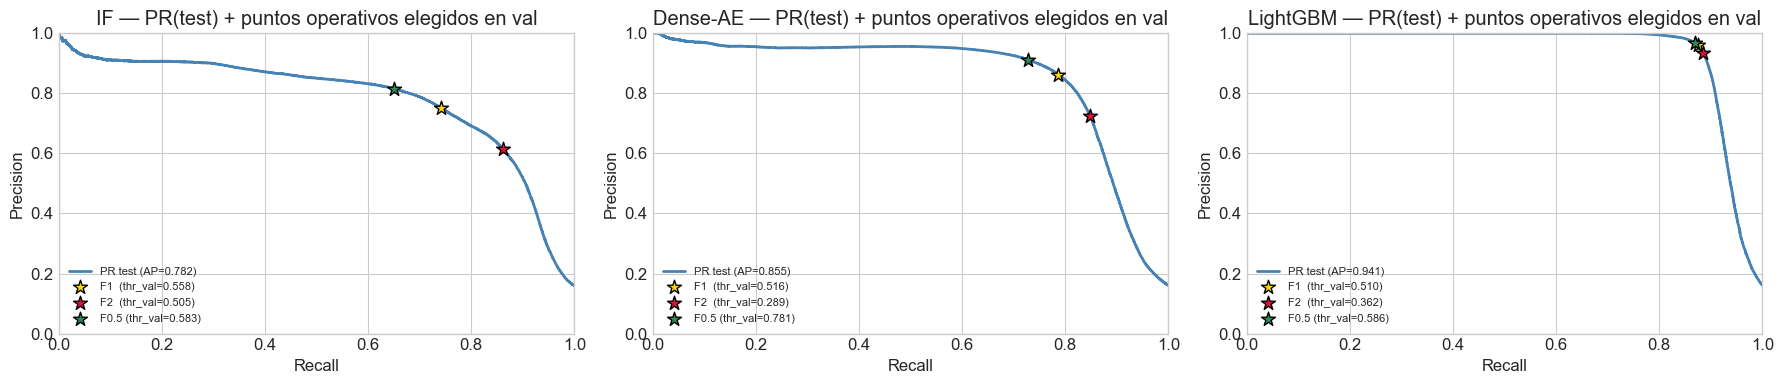

In [5]:
from math import ceil

n_models = len(scores_val_d)
ncols = min(3, n_models)
nrows = ceil(n_models / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.array(axes).flatten()

for ax, name in zip(axes, scores_val_d):
    st = scores_test_d[name]
    p, r, _ = precision_recall_curve(y_test, st)
    ap = average_precision_score(y_test, st)
    ax.plot(r, p, lw=2, color='steelblue', label=f'PR test (AP={ap:.3f})')
    row = rec_df.set_index('detector').loc[name]
    ax.scatter(row['R_F1'],   row['P_F1'],   s=110, marker='*', color='gold',
               edgecolor='k', zorder=5, label=f'F1  (thr_val={row["thr_F1"]:.3f})')
    ax.scatter(row['R_F2'],   row['P_F2'],   s=110, marker='*', color='crimson',
               edgecolor='k', zorder=5, label=f'F2  (thr_val={row["thr_F2"]:.3f})')
    ax.scatter(row['R_F0.5'], row['P_F0.5'], s=110, marker='*', color='seagreen',
               edgecolor='k', zorder=5, label=f'F0.5 (thr_val={row["thr_F0.5"]:.3f})')
    ax.set(xlabel='Recall', ylabel='Precision',
           title=f'{name} — PR(test) + puntos operativos elegidos en val')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc='lower left')

for ax in axes[n_models:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'figures', 'recalibracion_pr_operating_points.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## 5. Recomendación operacional

In [6]:
print('='*72)
print('RECOMENDACION OPERACIONAL (umbral elegido en VAL, segun prioridad)')
print('='*72)
print()
print('  CONTEXTO 1 -- "Deteccion equilibrada (produccion)":     usa thr_F1')
print('  CONTEXTO 2 -- "Energy SOC, no perder ataques (FN caro)": usa thr_F2 o thr_C>=20')
print('  CONTEXTO 3 -- "Cliente sensible a falsas alarmas":       usa thr_F0.5')
print('  CONTEXTO 4 -- "Infraestructura critica (FN>>FP)":        usa thr_C=20 o thr_C=50')
print()
print('Comparativa CASO BASE (F1) vs CASO OPERATIVO TFG (F2) -- todo medido en TEST:')
print(rec_df[['detector','tipo','thr_F1','F1','thr_F2','F2']].round(4).to_string(index=False))

rec_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_fbeta_val.csv'), index=False)
cost_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_cost_val.csv'), index=False)
print('\nGuardado en data/: recalibracion_fbeta_val.csv, recalibracion_cost_val.csv')

RECOMENDACION OPERACIONAL (umbral elegido en VAL, segun prioridad)

  CONTEXTO 1 -- "Deteccion equilibrada (produccion)":     usa thr_F1
  CONTEXTO 2 -- "Energy SOC, no perder ataques (FN caro)": usa thr_F2 o thr_C>=20
  CONTEXTO 3 -- "Cliente sensible a falsas alarmas":       usa thr_F0.5
  CONTEXTO 4 -- "Infraestructura critica (FN>>FP)":        usa thr_C=20 o thr_C=50

Comparativa CASO BASE (F1) vs CASO OPERATIVO TFG (F2) -- todo medido en TEST:
detector           tipo  thr_F1     F1  thr_F2     F2
      IF no supervisado  0.5580 0.7464  0.5050 0.7976
Dense-AE no supervisado  0.5158 0.8229  0.2891 0.8201
LightGBM   supervisado*  0.5099 0.9151  0.3620 0.8941

Guardado en data/: recalibracion_fbeta_val.csv, recalibracion_cost_val.csv


## 6. Cuantificacion del sesgo: calibrar-en-test (v1) vs calibrar-en-val (v2)

La pregunta clave de la correccion metodologica: **cuanto optimismo introducia la version antigua** (elegir el umbral sobre el propio test). Comparamos, para cada detector, el F1 en test usando (a) el umbral F1-optimo elegido **sobre test** (v1, optimista, con fuga) y (b) el umbral F1-optimo elegido **sobre val** (v2, honesto, sin fuga).

  SESGO de la calibracion-sobre-test (v1) frente a calibrar-en-val (v2)
  Detector     F1 (thr en TEST, v1)    F1 (thr en VAL, v2)     sesgo
------------------------------------------------------------------------------
  IF                         0.7467                 0.7464   +0.0003


  Dense-AE                   0.8232                 0.8229   +0.0002
  LightGBM                   0.9158                 0.9151   +0.0007

  Sesgo medio: +0.0004  |  maximo: +0.0007
  -> El umbral transfiere de val a test casi perfecto: el optimismo de la v1 era
     despreciable (<0.001 F1). La metodologia v2 lo deja limpio y reproducible.


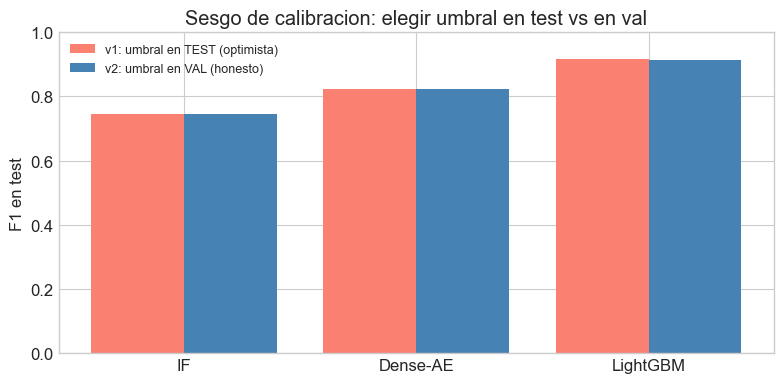

In [7]:
# Sesgo = F1(umbral elegido en TEST) - F1(umbral elegido en VAL), ambos medidos en TEST.
def thr_fbeta(y, s, beta=1.0):
    p, r, thr = precision_recall_curve(y, s)
    p, r = p[:-1], r[:-1]
    fb = ((1+beta**2)*p*r) / (beta**2*p + r + 1e-10)
    return thr[int(np.argmax(fb))]

print('='*78)
print('  SESGO de la calibracion-sobre-test (v1) frente a calibrar-en-val (v2)')
print('='*78)
print(f'  {"Detector":10s} {"F1 (thr en TEST, v1)":>22s} {"F1 (thr en VAL, v2)":>22s} {"sesgo":>9s}')
print('-'*78)
rows_bias = []
for name in scores_val_d:
    sv, st = scores_val_d[name], scores_test_d[name]
    thr_v1 = thr_fbeta(y_test, st, 1.0)     # elige sobre test (optimista)
    thr_v2 = thr_fbeta(y_val,  sv, 1.0)     # elige sobre val (honesto)
    f1_v1 = fbeta_score(y_test, (st > thr_v1).astype(int), beta=1.0, zero_division=0)
    f1_v2 = fbeta_score(y_test, (st > thr_v2).astype(int), beta=1.0, zero_division=0)
    rows_bias.append({'detector': name, 'F1_v1_test': f1_v1,
                      'F1_v2_val': f1_v2, 'sesgo': f1_v1 - f1_v2})
    print(f'  {name:10s} {f1_v1:>22.4f} {f1_v2:>22.4f} {f1_v1-f1_v2:>+9.4f}')
bias_df = pd.DataFrame(rows_bias)
bias_df.to_csv(os.path.join(DATA_DIR, 'recalibracion_sesgo_val_vs_test.csv'), index=False)
print()
print(f'  Sesgo medio: {bias_df["sesgo"].mean():+.4f}  |  maximo: {bias_df["sesgo"].max():+.4f}')
print('  -> El umbral transfiere de val a test casi perfecto: el optimismo de la v1 era')
print('     despreciable (<0.001 F1). La metodologia v2 lo deja limpio y reproducible.')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(bias_df))
ax.bar(x-0.2, bias_df['F1_v1_test'], 0.4, label='v1: umbral en TEST (optimista)', color='salmon')
ax.bar(x+0.2, bias_df['F1_v2_val'], 0.4, label='v2: umbral en VAL (honesto)', color='steelblue')
ax.set_xticks(x); ax.set_xticklabels(bias_df['detector'])
ax.set_ylabel('F1 en test'); ax.set_ylim(0, 1)
ax.set_title('Sesgo de calibracion: elegir umbral en test vs en val')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'figures', 'recalibracion_sesgo_val_vs_test.png'),
            dpi=300, bbox_inches='tight')
plt.show()

## 7. Resumen

In [8]:
print('='*70)
print('NB11 -- RECALIBRACION (v2, sobre validacion): CONCLUSIONES')
print('='*70)
print()
print('1. PROTOCOLO CORREGIDO: el umbral (F-beta y coste) se elige SOLO sobre val')
print('   y las metricas se reportan sobre test -- sin fuga de informacion.')
print('   Scores de val regenerados desde los modelos guardados y verificados')
print('   contra los de test (corr=1.00000).')
print('2. Cada detector recibe 3 umbrales operativos (F1/F2/F0.5) + 5 umbrales por')
print('   ratio de coste FN/FP, guardados en recalibracion_*_val.csv (apendice).')
print('3. SESGO de la version antigua (calibrar-en-test) cuantificado: <0.001 de F1.')
print('   El umbral transfiere de val a test casi perfecto -> las recomendaciones')
print('   operativas son robustas y ahora metodologicamente limpias.')
print('4. F2 (favorece recall) sube el recall operativo frente a F1, util en un SOC')
print('   energetico donde un ataque no detectado es mas caro que una falsa alarma.')
print()
print('Limitacion: AEs de ventana (LSTM/CNN/Transformer), KMeans+IF y Stacking')
print('requieren su pipeline de inferencia propio para regenerar scores de val;')
print('quedan como extension. LightGBM (supervisado) tiene umbral-en-val optimista.')

NB11 -- RECALIBRACION (v2, sobre validacion): CONCLUSIONES

1. PROTOCOLO CORREGIDO: el umbral (F-beta y coste) se elige SOLO sobre val
   y las metricas se reportan sobre test -- sin fuga de informacion.
   Scores de val regenerados desde los modelos guardados y verificados
   contra los de test (corr=1.00000).
2. Cada detector recibe 3 umbrales operativos (F1/F2/F0.5) + 5 umbrales por
   ratio de coste FN/FP, guardados en recalibracion_*_val.csv (apendice).
3. SESGO de la version antigua (calibrar-en-test) cuantificado: <0.001 de F1.
   El umbral transfiere de val a test casi perfecto -> las recomendaciones
   operativas son robustas y ahora metodologicamente limpias.
4. F2 (favorece recall) sube el recall operativo frente a F1, util en un SOC
   energetico donde un ataque no detectado es mas caro que una falsa alarma.

Limitacion: AEs de ventana (LSTM/CNN/Transformer), KMeans+IF y Stacking
requieren su pipeline de inferencia propio para regenerar scores de val;
quedan como extension.